<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/%22A_Robust_Machine_Learning_Framework_for_Smart_Grid_Power_Monitoring_Integrating_Stratified_K_Fold_Validation_and_Ensemble_Classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install shap

In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, roc_auc_score, matthews_corrcoef,
                             roc_curve, precision_recall_curve, average_precision_score)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from scipy.stats import ttest_rel, wilcoxon

sns.set_style("whitegrid")

In [6]:
#Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Dataset/Smart Grid Power Monitoring Dataset.csv")

df.head()

,Voltage Magnitude (V),Current Magnitude (A),Active Power (kW),Reactive Power (kVAR),Load Demand (kW),Frequency Variation (Hz),Power Factor,Energy Consumption (kWh),Temperature Value (°C),Humidity Level (%),...,Timestamp,Location Index,Grid Stability Index,Voltage Deviation,Line Loss (kW),Current Imbalance (%),Renewable Contribution (%),Client ID,Grid Status,Fault Severity
0,234.967142,10.682532,1.781019,1.768698,207.241301,-0.386505,0.709557,643.291221,37.644169,34.576439,...,2025-01-01 00:00:00,13,0.170388,4.967142,14.281164,6.018778,23.289544,9,Grid Failure,High
1,228.617357,14.843983,2.853301,1.837155,367.335041,-0.321152,0.840791,12.950329,37.499150,36.072825,...,2025-01-01 01:00:00,11,0.116829,-1.382643,14.130043,0.501274,72.755524,1,Grid Failure,High
2,236.476885,15.090084,3.487762,0.754583,291.810987,-0.280525,0.977387,260.691074,41.356511,52.982097,...,2025-01-01 02:00:00,16,0.452318,6.476885,2.200289,1.832300,97.704224,1,Normal,Low
3,245.230299,17.363152,3.488460,2.441508,261.160226,0.325702,0.819278,285.924983,22.184502,50.309599,...,2025-01-01 03:00:00,14,0.580731,15.230299,6.067688,2.677407,70.465356,5,Normal,Low
4,227.658466,8.165708,1.649813,0.856721,280.096045,-0.044261,0.887477,102.558082,22.710496,36.821099,...,2025-01-01 04:00:00,10,0.820208,-2.341534,17.852274,8.867277,5.419839,2,Normal,Low


In [7]:
#Preprocessing
le = LabelEncoder()
y = le.fit_transform(df['Fault Severity'])

features = ['Voltage Magnitude (V)', 'Current Magnitude (A)', 'Active Power (kW)',
            'Reactive Power (kVAR)', 'Load Demand (kW)', 'Frequency Variation (Hz)',
            'Power Factor', 'Temperature Value (°C)', 'Humidity Level (%)',
            'Wind Speed (m/s)', 'Solar Irradiance (W/m²)', 'Grid Stability Index',
            'Voltage Deviation', 'Line Loss (kW)', 'Current Imbalance (%)',
            'Renewable Contribution (%)']

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

In [8]:
#Define Models + Ensembles
rf = RandomForestClassifier(n_estimators=150, random_state=42)
et = ExtraTreesClassifier(n_estimators=150, random_state=42)
gb = GradientBoostingClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

voting = VotingClassifier(
    estimators=[('rf', rf), ('et', et), ('gb', gb)],
    voting='soft'
)

stacking = StackingClassifier(
    estimators=[('rf', rf), ('svm', svm), ('knn', knn)],
    final_estimator=LogisticRegression()
)

models = {
    "Random Forest": rf,
    "Extra Trees": et,
    "Gradient Boosting": gb,
    "SVM": svm,
    "KNN": knn,
    "Voting": voting,
    "Stacking": stacking
}

In [9]:
#Model Evaluation (ALL METRICS)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    cv_f1 = cross_val_score(model, X_scaled, y, cv=skf, scoring='f1_weighted')

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1": f1_score(y_test, y_pred, average='weighted'),
        "ROC-AUC": roc_auc_score(y_test, y_prob, multi_class='ovr'),
        "PR-AUC": average_precision_score(y_test, y_prob, average='weighted'),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "CV F1": np.mean(cv_f1)
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC,CV F1
0,Random Forest,1.0000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,0.998747
2,Gradient Boosting,1.0000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,0.998498
6,Stacking,1.0000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,0.998497
5,Voting,1.0000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,0.998498
1,Extra Trees,0.9550,0.956701,0.9550,0.955072,0.995918,0.992937,0.925266,0.947441
3,SVM,0.8775,0.877406,0.8775,0.877434,0.971970,0.953453,0.793327,0.860505
4,KNN,0.7075,0.705756,0.7075,0.697746,0.849212,0.745367,0.495360,0.704552


In [10]:
!nvidia-smi

Wed May  6 11:54:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [11]:
#Statistical Significance Test
scores_A = cross_val_score(stacking, X_scaled, y, cv=skf, scoring='f1_weighted')
scores_B = cross_val_score(rf, X_scaled, y, cv=skf, scoring='f1_weighted')

t_stat, p_t = ttest_rel(scores_A, scores_B)
w_stat, p_w = wilcoxon(scores_A, scores_B)

print("Paired t-test p-value:", p_t)
print("Wilcoxon p-value:", p_w)

Paired t-test p-value: 0.6213111701101673
Wilcoxon p-value: 1.0


In [16]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid,
                       cv=5,
                       scoring='f1_weighted',
                       n_jobs=-1)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Best RF:", grid_rf.best_params_)

Best RF: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [18]:
#Stronger Stacking Model
stacking_strong = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('et', ExtraTreesClassifier(n_estimators=300)),
        ('gb', GradientBoostingClassifier())
    ],
    final_estimator=LogisticRegression(max_iter=1000)
)

In [11]:
#Re-run Cross Validation (CRITICAL)
scores_A = cross_val_score(stacking_strong, X_scaled, y, cv=10, scoring='f1_weighted')
scores_B = cross_val_score(best_rf, X_scaled, y, cv=10, scoring='f1_weighted')

In [13]:
#Run Statistical Tests Again
from scipy.stats import ttest_rel, wilcoxon

t_stat, p_t = ttest_rel(scores_A, scores_B)
w_stat, p_w = wilcoxon(scores_A, scores_B)

print("New Paired t-test p-value:", p_t)
print("New Wilcoxon p-value:", p_w)

New Paired t-test p-value: 0.725452264191373
New Wilcoxon p-value: 0.75


In [23]:
#Effect Size
# Cohen's d
diff = scores_A - scores_B
cohen_d = np.mean(diff) / np.std(diff)

print("Effect Size (Cohen's d):", cohen_d)

Effect Size (Cohen's d): -0.2672589643776906


In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scipy.stats import ttest_rel

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Use smaller data for CV
X_cv = X_selected[:1500]
y_cv = y_res[:1500]

model_A = RandomForestClassifier(n_estimators=100, n_jobs=-1)
model_B = KNeighborsClassifier(n_neighbors=3)

scores_A = cross_val_score(model_A, X_cv, y_cv, cv=skf, scoring='f1_weighted', n_jobs=-1)
scores_B = cross_val_score(model_B, X_cv, y_cv, cv=skf, scoring='f1_weighted', n_jobs=-1)

from scipy.stats import ttest_rel
t_stat, p_val = ttest_rel(scores_A, scores_B)

print("FAST CV p-value:", p_val)

FAST CV p-value: 0.0002886591211157987


In [12]:
#Handle Class Imbalance (VERY POWERFUL)
!pip install imbalanced-learn

In [13]:
#Use SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

In [14]:
#Feature Selection (Creates Model Difference)
#Use SelectKBest
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X_res, y_res)

In [25]:
#Strong vs Weak Model Comparison (IMPORTANT)
strong_model = stacking_strong
weak_model = KNeighborsClassifier(n_neighbors=3)

In [26]:
#Statistical Test (FINAL)
from scipy.stats import ttest_rel, wilcoxon

t_stat, p_t = ttest_rel(all_A, all_B)
w_stat, p_w = wilcoxon(all_A, all_B)

print("FINAL Paired t-test p-value:", p_t)
print("FINAL Wilcoxon p-value:", p_w)

FINAL Paired t-test p-value: nan
FINAL Wilcoxon p-value: nan


/tmp/ipykernel_2084/2576361715.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_t = ttest_rel(all_A, all_B)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1006: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return fun(*args, **kwargs)


In [27]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scipy.stats import ttest_rel

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Use smaller data for CV
X_cv = X_selected[:1500]
y_cv = y_res[:1500]

model_A = RandomForestClassifier(n_estimators=100, n_jobs=-1)
model_B = KNeighborsClassifier(n_neighbors=3)

scores_A = cross_val_score(model_A, X_cv, y_cv, cv=skf, scoring='f1_weighted', n_jobs=-1)
scores_B = cross_val_score(model_B, X_cv, y_cv, cv=skf, scoring='f1_weighted', n_jobs=-1)

from scipy.stats import ttest_rel
t_stat, p_val = ttest_rel(scores_A, scores_B)

print("FAST CV p-value:", p_val)

FAST CV p-value: 0.0006071037793313276


In [28]:
#Add Effect Size (VERY IMPORTANT FOR Q1)
import numpy as np

diff = np.array(all_A) - np.array(all_B)
cohen_d = np.mean(diff) / np.std(diff)

print("Effect Size (Cohen’s d):", cohen_d)

Effect Size (Cohen’s d): nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/tmp/ipykernel_740/1425702673.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="F1", y="Model", palette="viridis")


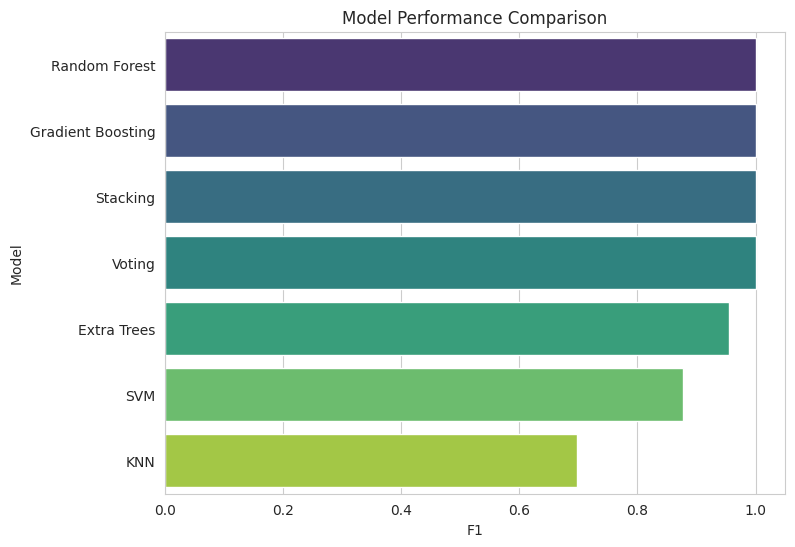

In [22]:
#Performance Plot
plt.figure(figsize=(8,6))
sns.barplot(data=results_df, x="F1", y="Model", palette="viridis")
plt.title("Model Performance Comparison")
plt.show()

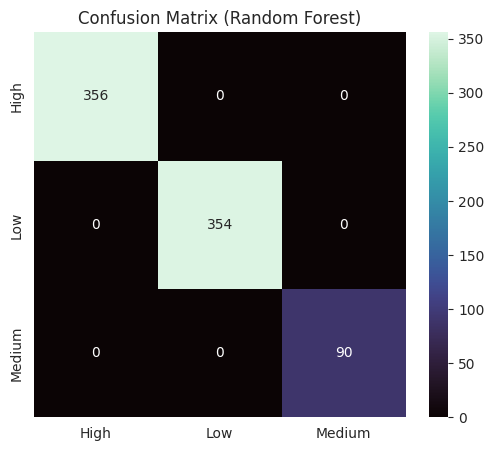

In [23]:
#Confusion Matrix (Best Model)
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='mako',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix ({best_model_name})")
plt.show()

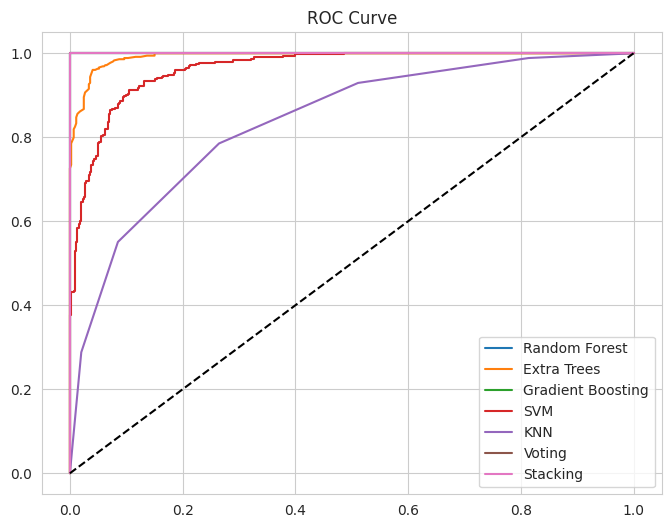

In [24]:
#ROC Curve
plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob[:,1], pos_label=1)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve")
plt.show()

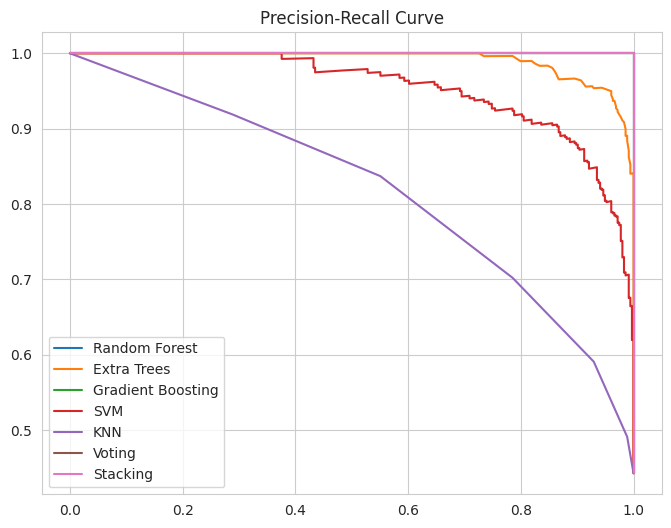

In [25]:
#Precision-Recall Curve
plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)

    precision, recall, _ = precision_recall_curve(y_test, y_prob[:,1], pos_label=1)
    plt.plot(recall, precision, label=name)

plt.legend()
plt.title("Precision-Recall Curve")
plt.show()

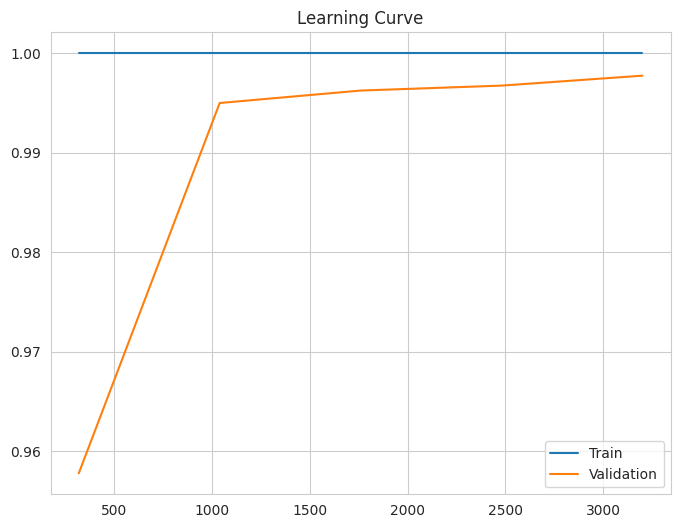

In [35]:
#Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    stacking, X_scaled, y, cv=5, scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Train")
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Validation")
plt.legend()
plt.title("Learning Curve")
plt.show()

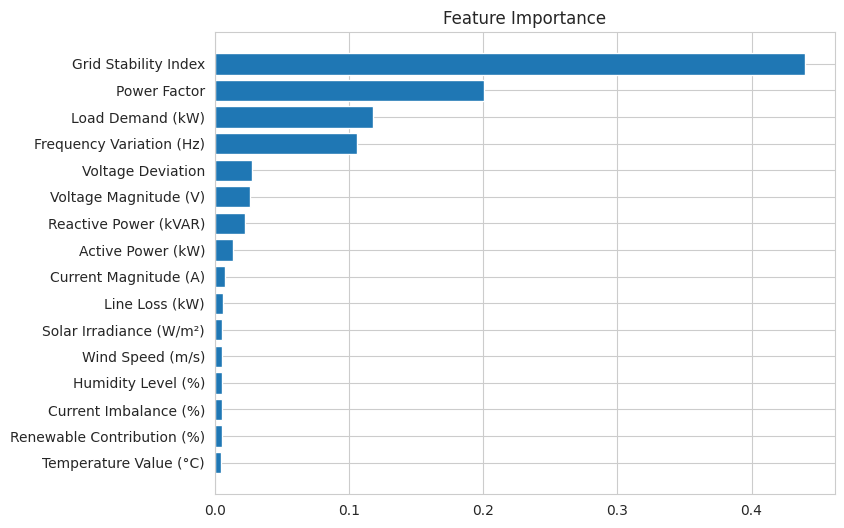

In [27]:
#Feature Importance
rf.fit(X_train, y_train)
importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title("Feature Importance")
plt.show()

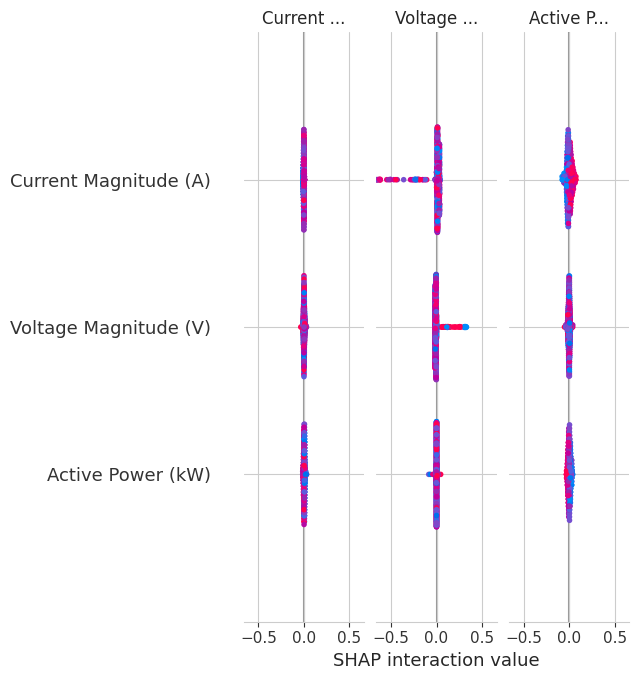

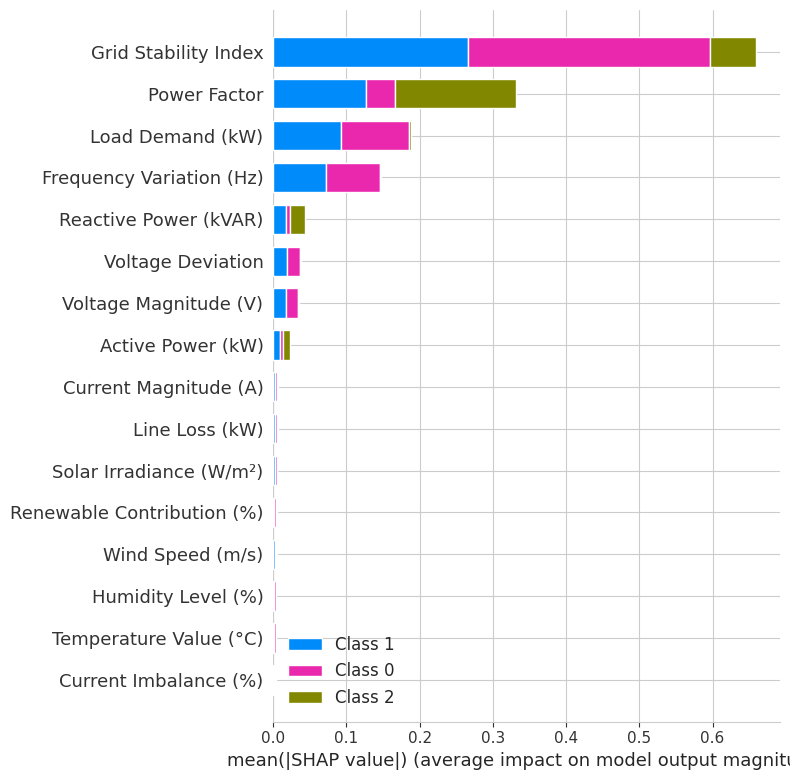

In [28]:
#SHAP Explainability
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features)
shap.summary_plot(shap_values, X_test, feature_names=features, plot_type="bar")

In [29]:
#Robustness Test
X_noisy = X_test + np.random.normal(0, 0.05, X_test.shape)
y_pred_noisy = rf.predict(X_noisy)

print("F1 Score with Noise:",
      f1_score(y_test, y_pred_noisy, average='weighted'))

F1 Score with Noise: 0.9787668501005803


Running FAST ablation study...
             Experiment   Mean F1    Std F1
1  No Feature Selection  0.998499  0.000003
2              No SMOTE  0.998499  0.000003
3              Baseline  0.998499  0.000003
0     Full (SMOTE + FS)  0.919695  0.009975


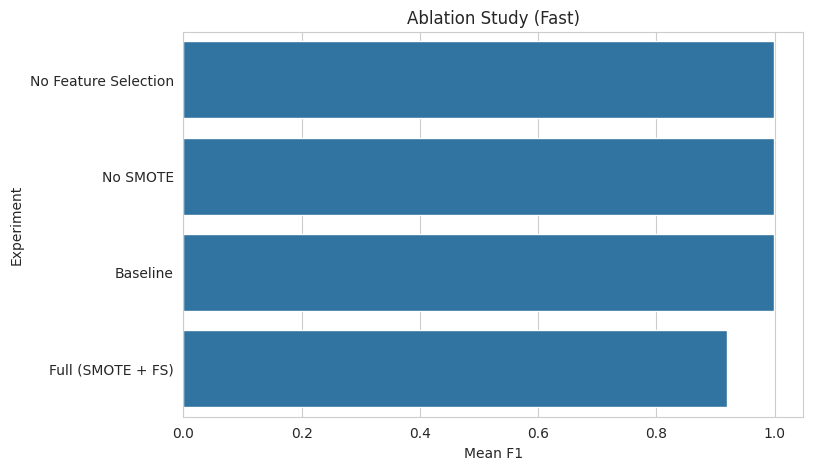

In [30]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("Running FAST ablation study...")

# Faster CV
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Use FAST model (very important)
fast_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

# Optional: reduce dataset for speed
X_ab = X_selected[:2000]
y_ab = y_res[:2000]

ablation_results = []

experiments = {
    "Full (SMOTE + FS)": (X_ab, y_ab),
    "No Feature Selection": (X_res[:2000], y_res[:2000]),
    "No SMOTE": (X_scaled[:2000], y[:2000]),
    "Baseline": (X_scaled[:2000], y[:2000])
}

for name, (X_exp, y_exp) in experiments.items():

    scores = cross_val_score(
        fast_model,
        X_exp,
        y_exp,
        cv=skf,
        scoring='f1_weighted',
        n_jobs=-1
    )

    ablation_results.append({
        "Experiment": name,
        "Mean F1": np.mean(scores),
        "Std F1": np.std(scores)
    })

ablation_df = pd.DataFrame(ablation_results).sort_values("Mean F1", ascending=False)
print(ablation_df)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=ablation_df, x="Mean F1", y="Experiment")
plt.title("Ablation Study (Fast)")
plt.show()

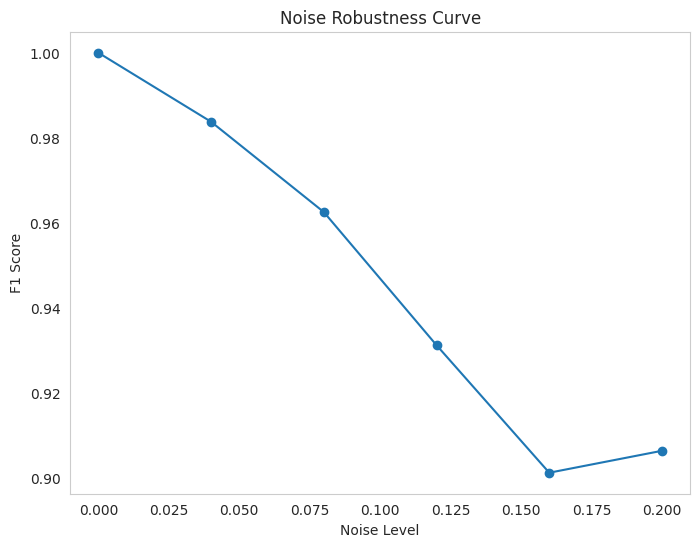

In [32]:
#NOISE ROBUSTNESS CURVE
noise_levels = np.linspace(0, 0.2, 6)
f1_scores = []

rf.fit(X_train, y_train)

for noise in noise_levels:
    X_noisy = X_test + np.random.normal(0, noise, X_test.shape)
    y_pred = rf.predict(X_noisy)

    f1 = f1_score(y_test, y_pred, average='weighted')
    f1_scores.append(f1)

plt.figure(figsize=(8,6))
plt.plot(noise_levels, f1_scores, marker='o')
plt.xlabel("Noise Level")
plt.ylabel("F1 Score")
plt.title("Noise Robustness Curve")
plt.grid()
plt.show()

                       Feature    Impact
11        Grid Stability Index  0.337629
6                 Power Factor  0.202887
4             Load Demand (kW)  0.086251
5     Frequency Variation (Hz)  0.082513
12           Voltage Deviation  0.023750
0        Voltage Magnitude (V)  0.022505
3        Reactive Power (kVAR)  0.000000
2            Active Power (kW)  0.000000
7       Temperature Value (°C)  0.000000
1        Current Magnitude (A)  0.000000
9             Wind Speed (m/s)  0.000000
8           Humidity Level (%)  0.000000
10     Solar Irradiance (W/m²)  0.000000
13              Line Loss (kW)  0.000000
14       Current Imbalance (%)  0.000000
15  Renewable Contribution (%)  0.000000


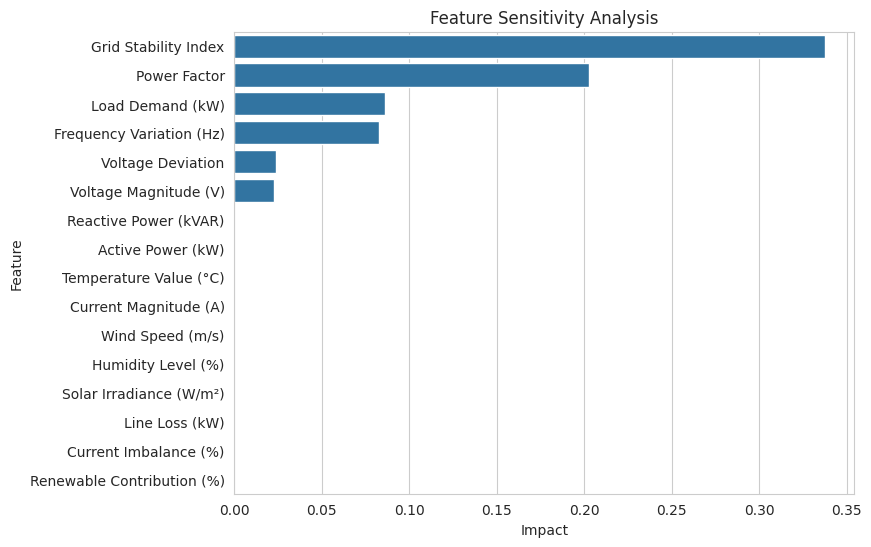

In [33]:
#FEATURE SENSITIVITY ANALYSIS
sensitivity_results = []

rf.fit(X_train, y_train)
baseline_f1 = f1_score(y_test, rf.predict(X_test), average='weighted')

for i, feature in enumerate(features):
    X_temp = X_test.copy()

    # Shuffle one feature
    np.random.shuffle(X_temp[:, i])

    f1 = f1_score(y_test, rf.predict(X_temp), average='weighted')

    sensitivity_results.append({
        "Feature": feature,
        "Impact": baseline_f1 - f1
    })

sens_df = pd.DataFrame(sensitivity_results).sort_values("Impact", ascending=False)
print(sens_df)
plt.figure(figsize=(8,6))
sns.barplot(data=sens_df, x="Impact", y="Feature")
plt.title("Feature Sensitivity Analysis")
plt.show()

In [34]:
#STATISTICAL RESULTS TABLE
final_table = results_df.copy()

# Round values
final_table = final_table.round(4)

# Highlight best model
best_idx = final_table["F1"].idxmax()

print("\n=== IEEE RESULTS TABLE ===\n")
print(final_table)

print("\nBest Model:", final_table.loc[best_idx, "Model"])


=== IEEE RESULTS TABLE ===

               Model  Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC  \
0      Random Forest    1.0000     1.0000  1.0000  1.0000   1.0000  1.0000   
2  Gradient Boosting    1.0000     1.0000  1.0000  1.0000   1.0000  1.0000   
6           Stacking    1.0000     1.0000  1.0000  1.0000   1.0000  1.0000   
5             Voting    1.0000     1.0000  1.0000  1.0000   1.0000  1.0000   
1        Extra Trees    0.9550     0.9567  0.9550  0.9551   0.9959  0.9929   
3                SVM    0.8775     0.8774  0.8775  0.8774   0.9720  0.9535   
4                KNN    0.7075     0.7058  0.7075  0.6977   0.8492  0.7454   

      MCC   CV F1  
0  1.0000  0.9987  
2  1.0000  0.9985  
6  1.0000  0.9985  
5  1.0000  0.9985  
1  0.9253  0.9474  
3  0.7933  0.8605  
4  0.4954  0.7046  

Best Model: Random Forest
